# Day 24 of ML 30-Days Challenge

# Task

**K-Means Clustering**: Your first unsupervised algorithm for finding clusters in data. Learn to use the elbow method to determine the optimal number of clusters and understand the algorithm's sensitivity to initial centroid placement.

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap

###1. Data preparation: create a n-row dataset

In [50]:
nkm=1000
X, y_true = make_blobs(
    n_samples=nkm,
    centers=4,
    cluster_std=1.1,
    random_state=42
)

###2. Elbow method: find optimal k by inertia curve

In [51]:
k_min, k_max = 1, 10
ks = list(range(k_min, k_max + 1))
inertias = []
for k in ks:
    km = KMeans(n_clusters=k, n_init='auto', random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

print("Inertias : \n\n", inertias)

Inertias : 

 [67299.89383032559, 31991.066466640834, 7735.17568161801, 2353.854802106006, 2145.978744833015, 1958.9208008054754, 1782.6847452310494, 1600.6099144831348, 1504.3226855284245, 1297.658008246144]


In [52]:
opt_k = 3
if len(ks) >= 3:
    diffs = np.diff(inertias)
    curvatures = np.diff(diffs)
    elbow_idx = np.argmin(curvatures) + 2
    opt_k = int(max(2, ks[elbow_idx]))

print("Optimal k :", opt_k)

Optimal k : 10


###3. Train final K-Means with optimal k

In [53]:
kmeans = KMeans(n_clusters=opt_k, n_init='auto', random_state=42)
labels = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

###4. Final visualization: one graph with clusters and centroids

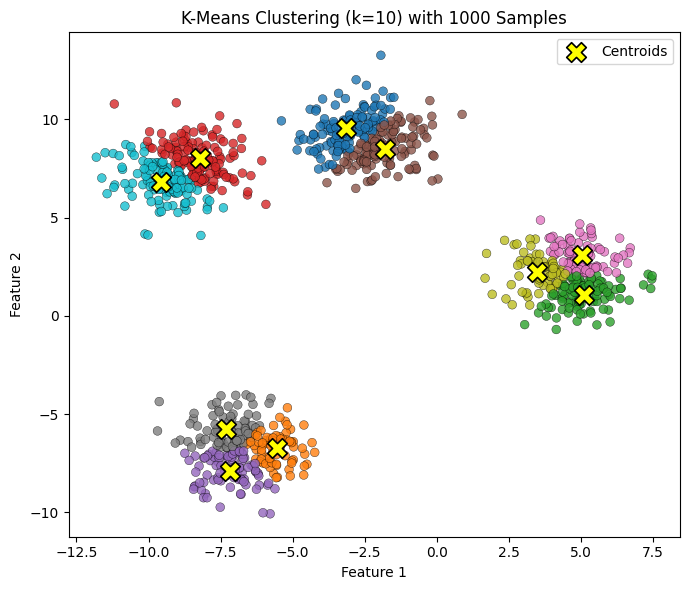

In [54]:
palette = ListedColormap([
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
    "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
    "#bcbd22", "#17becf"
])

plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap=palette, s=40, alpha=0.8, edgecolor='k', linewidths=0.3)
plt.scatter(centers[:, 0], centers[:, 1], c='yellow', s=200, edgecolor='black', marker='X', linewidths=1.2, label='Centroids')

plt.title(f'K-Means Clustering (k={opt_k}) with {nkm} Samples')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc='best')
plt.tight_layout()
plt.show()